# Physics for Scientists & Engineers

<img src="..//pics/cover.jpg" width=400> 


In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
!python --version

Python 3.12.10


In [3]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_Physics_4_SE_Serway_11\\ch05'

### Problems
#### Section 5.4 Newton’s Second Law
#### Problem 3

page 135

A 3.00-kg object undergoes an acceleration given by
$\vec{a}=(2.00\hat{i} + 5.00\hat{j})\; m/s^2$. 

Find

**(a)** the resultant force acting on the object and 

**(b)** the magnitude of the resultant
force.



In [ ]:
# vPython
print("(a)")
m = 3  # kg
a = vp.vec(2, 5, 0)  # m/s^2
F_res = m * a
print(f"Resultant force F_res = {F_res} N")


(a)
Resultant force F_res = <6, 15, 0> N


In [17]:
print("\n(b)")
print(f"Magnitude of resultant force F_res_mag = {F_res.mag:.1f} N")


(b)
Magnitude of resultant force F_res_mag = 16.2 N


#### Problem 4

page 135

The average speed of a nitrogen molecule in air is about
$6.70 \times 10^2 m/s$, and its mass is $4.68 \times 10^{-26} kg$. 

**(a)** If it
takes $3.00 \times 10^{-13} s$ for a nitrogen molecule to hit a wall
and rebound with the same speed but moving in the
opposite direction, what is the average acceleration of
the molecule during this time interval? 

**(b)** What average
force does the molecule exert on the wall?

In [ ]:
# AstroPy
v_i = 6.7e2 * (u.m / u.s)  # x-axis in the original direction of molecule's motion
v_f = -v_i
m = 4.68e-26 * u.kg
t = 3e-13 * u.s

# v_f = v_i + at ==> a = (v_f - v_i) / t
a = (v_f - v_i) / t
print("(a)")
print(f"Average acceleration a={a:.2e}")

(a)
Average acceleration a=-4.47e+15 m / s2


In [28]:
print("\n(b)")
F = m * a
F = F.to(u.N)
print(f"Average force F={F:.2e}")



(b)
Average force F=-2.09e-10 N


#### Problem 5

page 135

Two forces, $\vec{F_1} = (-6.00\hat{i} -4.00\hat{j}) N$ and 
$\vec{F_2} = (-3.00\hat{i} +7.00\hat{j}) N$, 
act on a particle of mass 2.00 kg that is initially
at rest at coordinates (-2.00 m, +4.00 m). 

**(a)** What are
the components of the particle’s velocity at $t = 10.0 s$?

**(b)** In what direction is the particle moving at $t = 10.0 s$?

**(c)** What displacement does the particle undergo during
the first 10.0 s? 

**(d)** What are the coordinates of the particle
at $t = 10.0 s$?

In [ ]:
# Define symbolic variables
m, t = sp.symbols("m t", real=True, positive=True)
F1x, F1y, F2x, F2y = sp.symbols("F1x F1y F2x F2y", real=True)
x0, y0 = sp.symbols("x0 y0", real=True)

# 1. Net Force components
Fnet_x = F1x + F2x
Fnet_y = F1y + F2y

# 2. Acceleration components
ax = Fnet_x / m
ay = Fnet_y / m

# 3. Kinematic expressions (starting from rest v0 = 0)
vx_t = ax * t
vy_t = ay * t

theta_dir = sp.atan2(vy_t, vx_t)

dx_t = sp.Rational(1, 2) * ax * t**2
dy_t = sp.Rational(1, 2) * ay * t**2

x_final = x0 + dx_t
y_final = y0 + dy_t

print("--- Symbolic Velocity Components ---")
display(Math(rf"v_x(t) = {sp.latex(vx_t)}"))
display(Math(rf"v_y(t) = {sp.latex(vy_t)}"))

print("\n--- Symbolic Displacement Components ---")
display(Math(rf"\Delta x(t) = {sp.latex(dx_t)}"))
display(Math(rf"\Delta y(t) = {sp.latex(dy_t)}"))

print("\n--- Symbolic Final Coordinates ---")
display(Math(rf"x(t) = {sp.latex(x_final)}"))
display(Math(rf"y(t) = {sp.latex(y_final)}"))

--- Symbolic Velocity Components ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- Symbolic Displacement Components ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>


--- Symbolic Final Coordinates ---


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# =====================================================================
# 1. LAMBDIFY SYMPY EXPRESSIONS
# =====================================================================
f_vx = sp.lambdify((m, t, F1x, F2x), vx_t, modules="numpy")
f_vy = sp.lambdify((m, t, F1y, F2y), vy_t, modules="numpy")

f_dx = sp.lambdify((m, t, F1x, F2x), dx_t, modules="numpy")
f_dy = sp.lambdify((m, t, F1y, F2y), dy_t, modules="numpy")

f_xf = sp.lambdify((m, t, F1x, F2x, x0), x_final, modules="numpy")
f_yf = sp.lambdify((m, t, F1y, F2y, y0), y_final, modules="numpy")

# =====================================================================
# 2. INPUT DATA WITH ASTROPY UNITS
# =====================================================================
m_val = 2.00 * u.kg
t_val = 10.0 * u.s

x0_val = -2.00 * u.m
y0_val = 4.00 * u.m

F1x_val, F1y_val = -6.00 * u.N, -4.00 * u.N
F2x_val, F2y_val = -3.00 * u.N, 7.00 * u.N

# Extract raw values for evaluation
m_num = m_val.value
t_num = t_val.value
F1x_num, F1y_num = F1x_val.value, F1y_val.value
F2x_num, F2y_num = F2x_val.value, F2y_val.value
x0_num, y0_num = x0_val.value, y0_val.value

# =====================================================================
# 3. NUMERICAL EVALUATION & RE-ATTACH UNITS
# =====================================================================
# (a) Velocity components
vx_res = f_vx(m_num, t_num, F1x_num, F2x_num) * (u.m / u.s)
vy_res = f_vy(m_num, t_num, F1y_num, F2y_num) * (u.m / u.s)

# (b) Motion direction
direction_deg = (np.degrees(np.arctan2(vy_res.value, vx_res.value)) % 360) * u.deg

# (c) Displacement components
dx_res = f_dx(m_num, t_num, F1x_num, F2x_num) * u.m
dy_res = f_dy(m_num, t_num, F1y_num, F2y_num) * u.m

# (d) Final coordinates
xf_res = f_xf(m_num, t_num, F1x_num, F2x_num, x0_num) * u.m
yf_res = f_yf(m_num, t_num, F1y_num, F2y_num, y0_num) * u.m

print("--- Part (a) Velocity Components at t = 10 s ---")
print(f"v_x : {vx_res:.2f}")
print(f"v_y : {vy_res:.2f}")

print("\n--- Part (b) Direction of Motion ---")
print(f"Angle relative to +x axis : {direction_deg:.1f}")

print("\n--- Part (c) Displacement during first 10 s ---")
print(f"Displacement vector : ({dx_res:.2f}, {dy_res:.2f})")

print("\n--- Part (d) Coordinates at t = 10 s ---")
print(f"Final coordinates : ({xf_res:.2f}, {yf_res:.2f})")

--- Part (a) Velocity Components at t = 10 s ---
v_x : -45.00 m / s
v_y : 15.00 m / s

--- Part (b) Direction of Motion ---
Angle relative to +x axis : 161.6 deg

--- Part (c) Displacement during first 10 s ---
Displacement vector : (-225.00 m, 75.00 m)

--- Part (d) Coordinates at t = 10 s ---
Final coordinates : (-227.00 m, 79.00 m)


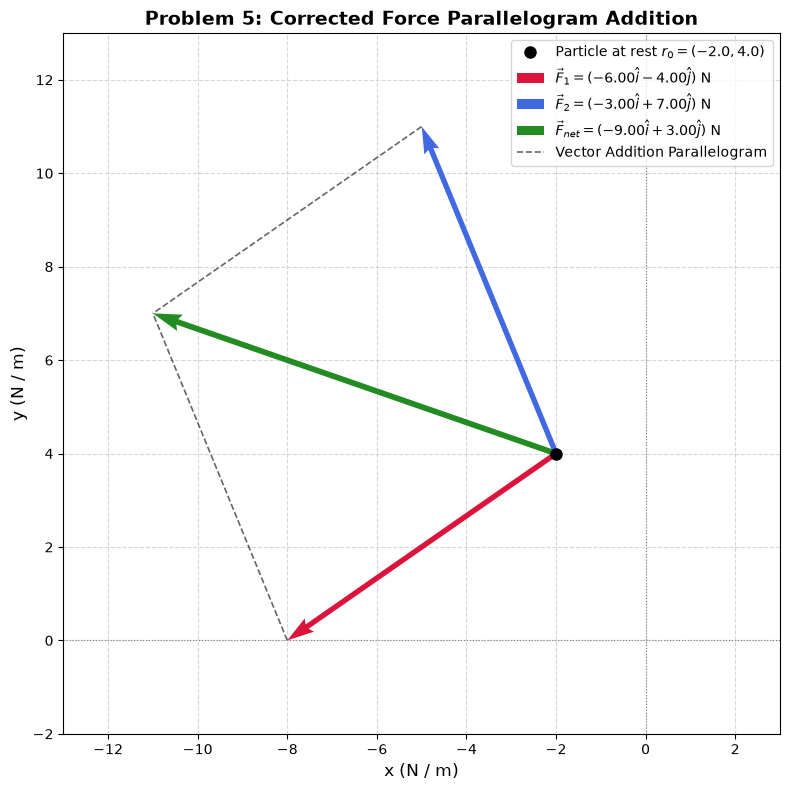

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define force components (in N)
F1 = np.array([-6.00, -4.00])
F2 = np.array([-3.00, 7.00])
F_net = F1 + F2

# Particle initial position (in m)
r0 = np.array([-2.00, 4.00])

# Tip positions relative to r0
tip_F1 = r0 + F1
tip_F2 = r0 + F2
tip_Fnet = r0 + F_net

plt.figure(figsize=(8, 8))

# 1. Plot the Particle Position
plt.plot(
    r0[0],
    r0[1],
    "ko",
    markersize=8,
    zorder=5,
    label=f"Particle at rest $r_0=({r0[0]}, {r0[1]})$",
)

# 2. Plot Force Vectors
plt.quiver(
    r0[0],
    r0[1],
    F1[0],
    F1[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="crimson",
    zorder=4,
    label=r"$\vec{F}_1 = (-6.00\hat{i} - 4.00\hat{j})\text{ N}$",
)

plt.quiver(
    r0[0],
    r0[1],
    F2[0],
    F2[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="royalblue",
    zorder=4,
    label=r"$\vec{F}_2 = (-3.00\hat{i} + 7.00\hat{j})\text{ N}$",
)

plt.quiver(
    r0[0],
    r0[1],
    F_net[0],
    F_net[1],
    angles="xy",
    scale_units="xy",
    scale=1,
    color="forestgreen",
    width=0.008,
    zorder=4,
    label=r"$\vec{F}_{net} = (-9.00\hat{i} + 3.00\hat{j})\text{ N}$",
)

# 3. Correct Parallelogram Lines (connecting tips properly)
# Line from Tip of F1 to Tip of Fnet
plt.plot(
    [tip_F1[0], tip_Fnet[0]],
    [tip_F1[1], tip_Fnet[1]],
    "k--",
    alpha=0.6,
    linewidth=1.2,
    label="Vector Addition Parallelogram",
)

# Line from Tip of F2 to Tip of Fnet
plt.plot(
    [tip_F2[0], tip_Fnet[0]], [tip_F2[1], tip_Fnet[1]], "k--", alpha=0.6, linewidth=1.2
)

# Grid & Limits Setup
plt.xlim(-13, 3)
plt.ylim(-2, 13)
plt.axhline(0, color="gray", linewidth=0.8, linestyle=":")
plt.axvline(0, color="gray", linewidth=0.8, linestyle=":")
plt.grid(True, linestyle="--", alpha=0.5)

plt.xlabel("x (N / m)", fontsize=12)
plt.ylabel("y (N / m)", fontsize=12)
plt.title(
    "Problem 5: Corrected Force Parallelogram Addition", fontsize=14, fontweight="bold"
)
plt.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

#### Problem 6

page 135

The force exerted by the wind on the sails of a sailboat
is 390 N north. The water exerts a force of 180 N east. If
the boat (including its crew) has a mass of 270 kg, what
are the magnitude and direction of its acceleration?

In [ ]:
F_wind = vp.vec(0, 390, 0)  # N due north
F_water = vp.vec(180, 0, 0)  # N due east
mass = 270  # kg

F_net = F_wind + F_water

# F = m * a ==> a = F / m
a = F_net / mass

# Apply astropy units
a_mag = a.mag * (u.m / u.s**2)

theta_rad = vp.atan2(a.y, a.x) * u.rad
theta_deg = theta_rad.to(u.deg)


print(f"Magnitud of acceleration = {a_mag:.2f} ")
print(f"Direction of acceleration = {theta_deg:.1f} (math angle, N of E)")


Magnitud of acceleration = 1.59 m / s2 
Direction of acceleration = 65.2 deg (math angle, N of E)


#### Problem 7

page 135

Review. Three forces acting on an object are given by
$\vec{F_1} = (-2.00\hat{i} +2.00\hat{j}) N$ , $\vec{F_2} = (5.00\hat{i} -3.00\hat{j}) N$, and
$\vec{F_3} = (-45.0\hat{i}) N$ . The object experiences an acceleration
of magnitude 3.75 m/s2. 

**(a)** What is the direction of the acceleration? 

**(b)** What is the mass of the object?

**(c)** If the object is initially at rest, what is its speed after
10.0 s? 

**(d)** What are the velocity components of the
object after 10.0 s?


In [ ]:
# vPython
F_1 = vp.vec(-2, 2, 0)
F_2 = vp.vec(5, -3, 0)
F_3 = vp.vec(-45, 0, 0)

F_net = F_1 + F_2 + F_3

print("(a)")
print(f"Resultant force F_net = {F_net} N")
F_net_theta_rad = vp.atan2(F_net.y, F_net.x) * u.rad
F_net_theta_deg = F_net_theta_rad.to(u.deg) % (360 * u.deg)
# a_hat_deg is the direction of the acceleration
a_hat_deg = F_net_theta_deg
print(f"Direcction of acceleration a_hat: {a_hat_deg:.0f}")

(a)
Resultant force F_net = <-42, -1, 0> N
Direcction of acceleration a_hat: 181 deg


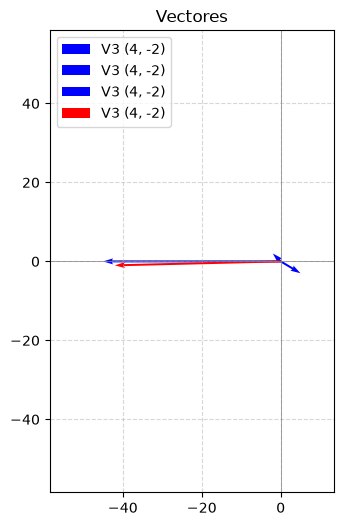

(<Axes: title={'center': 'Vectores'}>, (np.float64(2.8284271247461903), np.float64(135.0)))
(<Axes: title={'center': 'Vectores'}>, (np.float64(5.830951894845301), np.float64(-30.96375653207352)))
(<Axes: title={'center': 'Vectores'}>, (np.float64(45.0), np.float64(180.0)))


In [5]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import plot_vector, plot_vector_xy

# --- Ejemplo de uso combinando ambas funciones ---

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# just in case is needed we can use ret, normally not used
ret_1 = plot_vector_xy(-2, +2, ax=ax, color="b", label="V3 (4, -2)")
ret_2 = plot_vector_xy(5, -3, ax=ax, color="b", label="V3 (4, -2)")
ret_3 = plot_vector_xy(-45, 0, ax=ax, color="b", label="V3 (4, -2)")
ret_4 = plot_vector_xy(-42, -1, ax=ax, color="r", label="V3 (4, -2)")

plt.title("Vectores")
plt.show()

print(ret_1)
print(ret_2)
print(ret_3)

In [ ]:
print("(b)")
a_mag = 3.75 * (u.m / u.s**2)
F_net_mag = F_net.mag * (u.N)
# F = m a ==> m = F / a
m = F_net_mag / a_mag
print(f"Mass m={m.to(u.kg):.1f}")


(b)
Mass m=11.2 kg


In [ ]:
print("(c)")
t = 10 * u.s
v0 = 0 * (u.m / u.s)
# vf = v0 + at
vf_mag = v0 + a_mag * t
print(f"Speed after 10 s = {vf_mag}")


(c)
Speed after 10 s = 37.5 m / s


In [ ]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec

print("(d)")
# F = m a = m (vf/t) ==> vf = (F/m)* t
vf = (F_net / m.value) * t.value
print(f"Velocity components after 10s: {fmt_vec(vf)} m/s")

(d)
Velocity components after 10s: <-37.49, -0.89, 0.00> m/s
